In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="H6wzFmDuoOyuF9IFTFvS")
project = rf.workspace("roboflow-universe-projects").project("personal-protective-equipment-combined-model")
version = project.version(8)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Personal-Protective-Equipment---Combined-Model-8 in yolov8:: 100%|██████████| 88016/88016 [00:15<00:00, 5541.82it/s] 


Classes: ['Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest']
Num classes: 14
  Fall-Detected       : 3149 annotations
  Gloves              : 3381 annotations
  Goggles             : 2959 annotations
  Hardhat             : 28996 annotations
  Ladder              : 734 annotations
  Mask                : 1989 annotations
  NO-Gloves           : 4280 annotations
  NO-Goggles          : 2817 annotations
  NO-Hardhat          : 9705 annotations
  NO-Mask             : 1577 annotations
  NO-Safety Vest      : 1435 annotations
  Person              : 1034 annotations
  Safety Cone         : 9843 annotations
  Safety Vest         : 4499 annotations


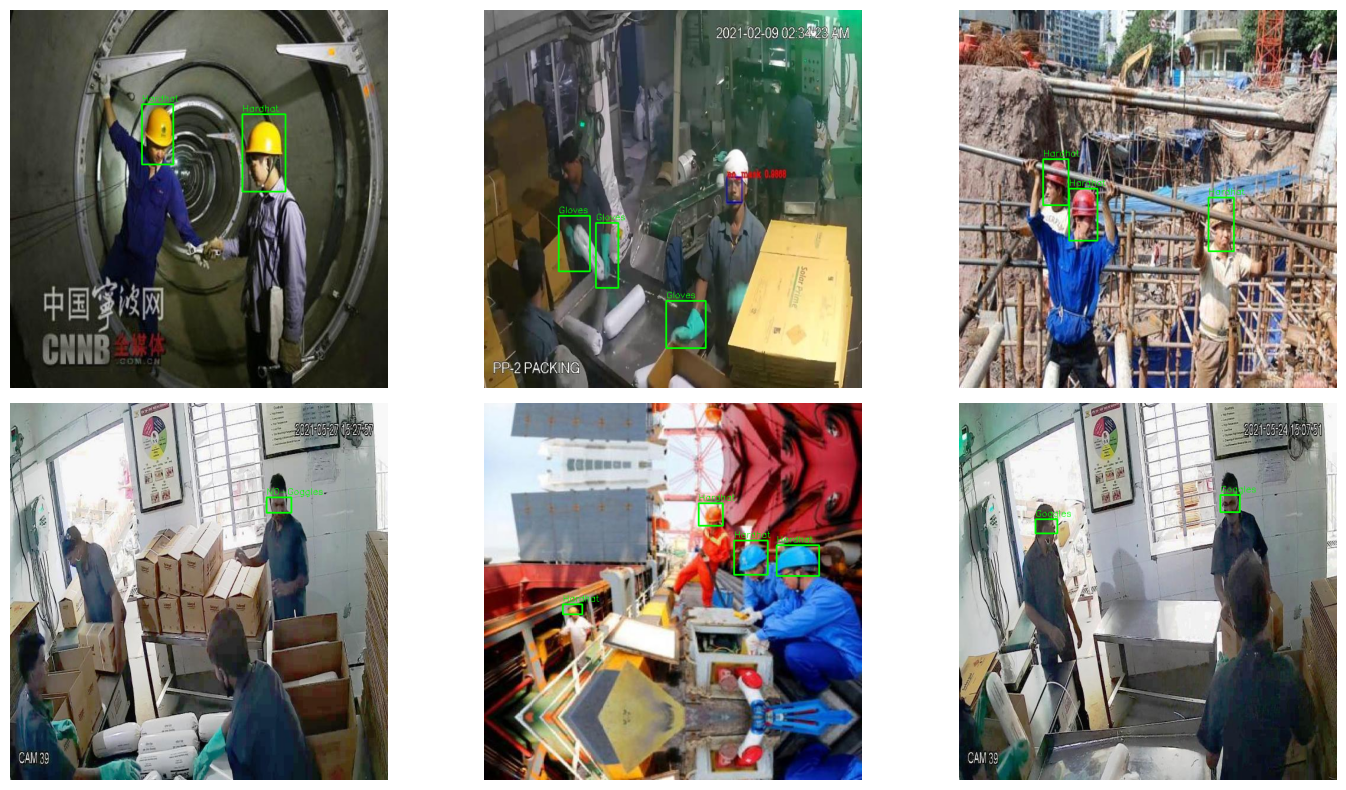

In [ ]:
import yaml, os, cv2, random
import matplotlib.pyplot as plt

with open("/content/Personal-Protective-Equipment---Combined-Model-8/data.yaml") as f:
    cfg = yaml.safe_load(f)

print("Classes:", cfg["names"])
print("Num classes:", cfg["nc"])

# Count annotations per class — catch imbalance before wasting GPU time
label_dir = "/content/Personal-Protective-Equipment---Combined-Model-8/train/labels"
class_counts = {i: 0 for i in range(cfg["nc"])}

for label_file in os.listdir(label_dir):
    with open(os.path.join(label_dir, label_file)) as f:
        for line in f:
            cls = int(line.split()[0])
            class_counts[cls] += 1

for cls_id, count in class_counts.items():
    print(f"  {cfg['names'][cls_id]:20s}: {count} annotations")

# Visualise 6 random training images with their boxes
img_dir = "/content/Personal-Protective-Equipment---Combined-Model-8/train/images"
images = random.sample(os.listdir(img_dir), 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, img_file in zip(axes.flat, images):
    img_path = os.path.join(img_dir, img_file)
    lbl_path = os.path.join(label_dir, img_file.replace(".jpg", ".txt").replace(".png", ".txt"))
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(lbl_path):
        with open(lbl_path) as lf:
            for line in lf:
                cls, cx, cy, bw, bh = map(float, line.split())
                x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
                cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
                cv2.putText(img, cfg["names"][int(cls)], (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
    ax.imshow(img); ax.axis("off")

plt.tight_layout()
plt.savefig("dataset_preview.png", dpi=100)
plt.show()

In [ ]:
!pip install ultralytics roboflow opencv-python supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.0 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import random
import yaml
from collections import defaultdict
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG — change these to match your setup
# ─────────────────────────────────────────────────────────────────────────────

DATASET_PATH = "/content/Personal-Protective-Equipment---Combined-Model-8"  # your downloaded folder
OUTPUT_PATH  = "ppe_reduced"   # where the trimmed dataset will be saved
MAX_PER_CLASS = 500            # max images per class across the whole dataset
SEED          = 42             # reproducibility

# Classes to KEEP — everything else gets dropped completely
# Original 14 classes: Hardhat, Mask, NO-Hardhat, NO-Mask, NO-Safety Vest,
#                      Person, Safety Vest, Goggles, NO-Goggles, Gloves,
#                      NO-Gloves, Ladder, Safety Cone, Fall-Detected
#
# We keep the 6 core compliance classes — the ones that matter for the demo
KEEP_CLASSES = [
    "Hardhat",
    "NO-Hardhat",
    "Safety Vest",
    "NO-Safety Vest",
    "Person",
    "Mask",          # swap out for NO-Mask if you prefer the violation version
]

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — Load original data.yaml and build class remapping
# ─────────────────────────────────────────────────────────────────────────────

yaml_path = os.path.join(DATASET_PATH, "data.yaml")

with open(yaml_path) as f:
    cfg = yaml.safe_load(f)

original_classes = cfg["names"]   # e.g. ['Hardhat', 'Mask', 'NO-Hardhat', ...]
print(f"Original dataset: {len(original_classes)} classes")
print(f"  {original_classes}\n")

# Validate that all KEEP_CLASSES actually exist in the dataset
for cls in KEEP_CLASSES:
    if cls not in original_classes:
        raise ValueError(
            f"'{cls}' not found in dataset. "
            f"Available classes: {original_classes}"
        )

# Build mapping: old class ID → new class ID (or None if dropped)
old_to_new = {}
new_class_list = []

for old_id, name in enumerate(original_classes):
    if name in KEEP_CLASSES:
        new_id = KEEP_CLASSES.index(name)  # preserves your chosen order
        old_to_new[old_id] = new_id
    else:
        old_to_new[old_id] = None  # will be dropped

print("Class ID remapping:")
for old_id, name in enumerate(original_classes):
    new_id = old_to_new[old_id]
    status = f"→ new id {new_id}" if new_id is not None else "→ DROPPED"
    print(f"  [{old_id:2d}] {name:20s} {status}")

print(f"\nKeeping {len(KEEP_CLASSES)} classes: {KEEP_CLASSES}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — Scan ALL label files and index which images contain each class
# ─────────────────────────────────────────────────────────────────────────────

# Map: new_class_id → list of (split, image_filename)
class_to_images = defaultdict(list)

# Also store: image_path → list of kept annotation lines
# We need this to rewrite labels after filtering
image_annotations = {}

for split in ["train", "valid", "test"]:
    img_dir = Path(DATASET_PATH) / split / "images"
    lbl_dir = Path(DATASET_PATH) / split / "labels"

    if not img_dir.exists():
        print(f"  Split '{split}' not found, skipping.")
        continue

    for lbl_file in lbl_dir.glob("*.txt"):
        img_file = img_dir / (lbl_file.stem + ".jpg")
        if not img_file.exists():
            img_file = img_dir / (lbl_file.stem + ".png")
        if not img_file.exists():
            continue  # no matching image

        kept_lines = []
        classes_in_image = set()

        with open(lbl_file) as f:
            for line in f.read().strip().splitlines():
                parts = line.split()
                if len(parts) != 5:
                    continue
                old_id = int(parts[0])
                new_id = old_to_new.get(old_id)
                if new_id is not None:
                    # Rewrite with new class ID, keep bbox coords unchanged
                    new_line = f"{new_id} {' '.join(parts[1:])}"
                    kept_lines.append(new_line)
                    classes_in_image.add(new_id)

        # Only keep images that have at least one kept annotation
        if kept_lines:
            key = (split, str(img_file))
            image_annotations[key] = kept_lines
            for cls_id in classes_in_image:
                class_to_images[cls_id].append((split, str(img_file)))

print("\nImages containing each kept class (before cap):")
for cls_id, name in enumerate(KEEP_CLASSES):
    count = len(class_to_images[cls_id])
    print(f"  [{cls_id}] {name:20s}: {count:5d} images")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — Select images to keep, respecting MAX_PER_CLASS
# ─────────────────────────────────────────────────────────────────────────────

random.seed(SEED)

# We do a greedy selection: iterate classes in order, sample up to MAX_PER_CLASS
# images per class. An image with multiple kept classes counts toward all of them.

selected_images = set()  # set of (split, img_path) tuples

for cls_id, name in enumerate(KEEP_CLASSES):
    candidates = class_to_images[cls_id]
    random.shuffle(candidates)

    count = 0
    for item in candidates:
        if count >= MAX_PER_CLASS:
            break
        selected_images.add(item)
        count += 1

    # Some already-selected images may cover this class — recount
    already = sum(1 for img in selected_images if img in class_to_images[cls_id])
    print(f"  [{cls_id}] {name:20s}: selected {already:4d} / {MAX_PER_CLASS} cap")

print(f"\nTotal unique images selected: {len(selected_images)}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — Copy selected images + rewritten labels to output directory
# ─────────────────────────────────────────────────────────────────────────────

# Clean output dir if it exists
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
    print(f"Removed existing '{OUTPUT_PATH}'")

copied = defaultdict(int)

for split, img_path_str in selected_images:
    img_path = Path(img_path_str)
    lbl_path = Path(DATASET_PATH) / split / "labels" / (img_path.stem + ".txt")
    key = (split, img_path_str)

    if key not in image_annotations:
        continue

    # Create output directories
    out_img_dir = Path(OUTPUT_PATH) / split / "images"
    out_lbl_dir = Path(OUTPUT_PATH) / split / "labels"
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    # Copy image
    shutil.copy2(img_path, out_img_dir / img_path.name)

    # Write rewritten label file (new class IDs, dropped classes removed)
    out_lbl_path = out_lbl_dir / (img_path.stem + ".txt")
    with open(out_lbl_path, "w") as f:
        f.write("\n".join(image_annotations[key]))

    copied[split] += 1

print("\nCopied to output directory:")
for split in ["train", "valid", "test"]:
    print(f"  {split:6s}: {copied[split]:4d} images")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — Write clean data.yaml for the reduced dataset
# ─────────────────────────────────────────────────────────────────────────────

new_yaml = {
    "path":  str(Path(OUTPUT_PATH).resolve()),
    "train": "train/images",
    "val":   "valid/images",
    "test":  "test/images",
    "nc":    len(KEEP_CLASSES),
    "names": KEEP_CLASSES,
}

out_yaml_path = Path(OUTPUT_PATH) / "data.yaml"
with open(out_yaml_path, "w") as f:
    yaml.dump(new_yaml, f, default_flow_style=False, sort_keys=False)

print(f"\nWrote data.yaml → {out_yaml_path}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — Final verification: count annotations per class in output
# ─────────────────────────────────────────────────────────────────────────────

print("\n── Final dataset stats ──────────────────────────────")
final_counts = defaultdict(int)
total_images = 0

for split in ["train", "valid", "test"]:
    lbl_dir = Path(OUTPUT_PATH) / split / "labels"
    if not lbl_dir.exists():
        continue
    for lbl_file in lbl_dir.glob("*.txt"):
        total_images += 1
        with open(lbl_file) as f:
            for line in f.read().strip().splitlines():
                parts = line.split()
                if parts:
                    final_counts[int(parts[0])] += 1

print(f"Total images: {total_images}")
print(f"Annotations per class:")
for cls_id, name in enumerate(KEEP_CLASSES):
    bar_len = int(final_counts[cls_id] / max(final_counts.values()) * 30)
    bar = "█" * bar_len
    print(f"  [{cls_id}] {name:20s}: {final_counts[cls_id]:5d}  {bar}")

print(f"\nYour reduced dataset is ready at: '{OUTPUT_PATH}/'")
print(f"Use this in your training script:")
print(f"  model.train(data='{out_yaml_path}', ...)")

Original dataset: 14 classes
  ['Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest']

Class ID remapping:
  [ 0] Fall-Detected        → DROPPED
  [ 1] Gloves               → DROPPED
  [ 2] Goggles              → DROPPED
  [ 3] Hardhat              → new id 0
  [ 4] Ladder               → DROPPED
  [ 5] Mask                 → new id 5
  [ 6] NO-Gloves            → DROPPED
  [ 7] NO-Goggles           → DROPPED
  [ 8] NO-Hardhat           → new id 1
  [ 9] NO-Mask              → DROPPED
  [10] NO-Safety Vest       → new id 3
  [11] Person               → new id 4
  [12] Safety Cone          → DROPPED
  [13] Safety Vest          → new id 2

Keeping 6 classes: ['Hardhat', 'NO-Hardhat', 'Safety Vest', 'NO-Safety Vest', 'Person', 'Mask']

Images containing each kept class (before cap):
  [0] Hardhat             : 15477 images
  [1] NO-Hardhat          :  4925 images
  [2

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")   # nano — trains ~4x faster than small, good enough for 500/class

results = model.train(
    data="ppe_reduced/data.yaml",   # ← your reduced dataset
    epochs=60,                       # fewer epochs needed — smaller dataset converges faster
    patience=15,
    imgsz=640,
    batch=32,                        # can increase batch since dataset is smaller
    device=0,
    project="runs/ppe",
    name="reduced_v1",
    pretrained=True,
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=ppe_reduced/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=reduced_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspe

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/runs/ppe/reduced_v1/weights/best.pt")
metrics = model.val(data="/content/ppe_reduced/data.yaml", split="test")

print(f"\nmAP50:     {metrics.box.map50:.3f}")
print(f"mAP50-95:  {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall:    {metrics.box.mr:.3f}")

print("\nPer-class AP:")
for i, name in enumerate(model.names.values()):
    print(f"  {name:20s}: {metrics.box.ap[i]:.3f}")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 959.0±310.3 MB/s, size: 51.3 KB)
val: Scanning /content/ppe_reduced/test/labels... 304 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 304/304 1.9Kit/s 0.2s
val: New cache created: /content/ppe_reduced/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.6it/s 7.2s
                   all        304        698      0.683      0.722      0.676      0.441
               Hardhat         55        144      0.616      0.604      0.581      0.308
            NO-Hardhat         53        166      0.691      0.662      0.688      0.433
           Safety Vest         64        129       0.76      0.682      0.731      0.492
        NO-Safety Vest         56        123      0.543       0.61      0.498   